In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

In [2]:
data= load_data()



/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [3]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

In [4]:
target = "t_seasdiff"

In [5]:
check_stationarity(data_sd[target], regression='c')

ADF Statistic: -7.218881381427682
p-value: 2.137130843154981e-10
Stationary
KPSS Statistic: 0.019218132045905424
p-value: 0.1
Stationary


/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


In [6]:
cand_res = sarima_candidates_from_acf(
    data['t_seasdiff'],
    m=12,
    max_p=3,
    max_q=3,
    max_P=3,
    max_Q=3,
    max_lag=50
)

candidates = cand_res["candidates"]

for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,1)(0,0,0,12)
03. SARIMA(1,0,0)(0,0,0,12)
04. SARIMA(1,0,1)(0,0,0,12)


In [7]:
train_years = 9
h = 12
train_size = train_years * h

best_info, scores_df = select_best_sarima_cv(
    df=data_sd,
    target=target,
    candidates=candidates,
    forecast_window=h,
    train_size=train_size,
    step=h,       # 1 year
    metric="rmse",
)



/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py

01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9297, mean MAE=1.5438


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py

02. SARIMA(0,0,1)(0,0,0,12) - mean RMSE=1.9183, mean MAE=1.5369
03. SARIMA(1,0,0)(0,0,0,12) - mean RMSE=1.9220, mean MAE=1.5402


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py

04. SARIMA(1,0,1)(0,0,0,12) - mean RMSE=1.9349, mean MAE=1.5545

=== BEST BY ROLLING CV ===
Metric: rmse
Best order:        (0, 0, 1)
Best seasonal:     (0, 0, 0, 12)
Best mean RMSE:    1.9182966586605226
Best mean MAE:     1.5368694900987232


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py

/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


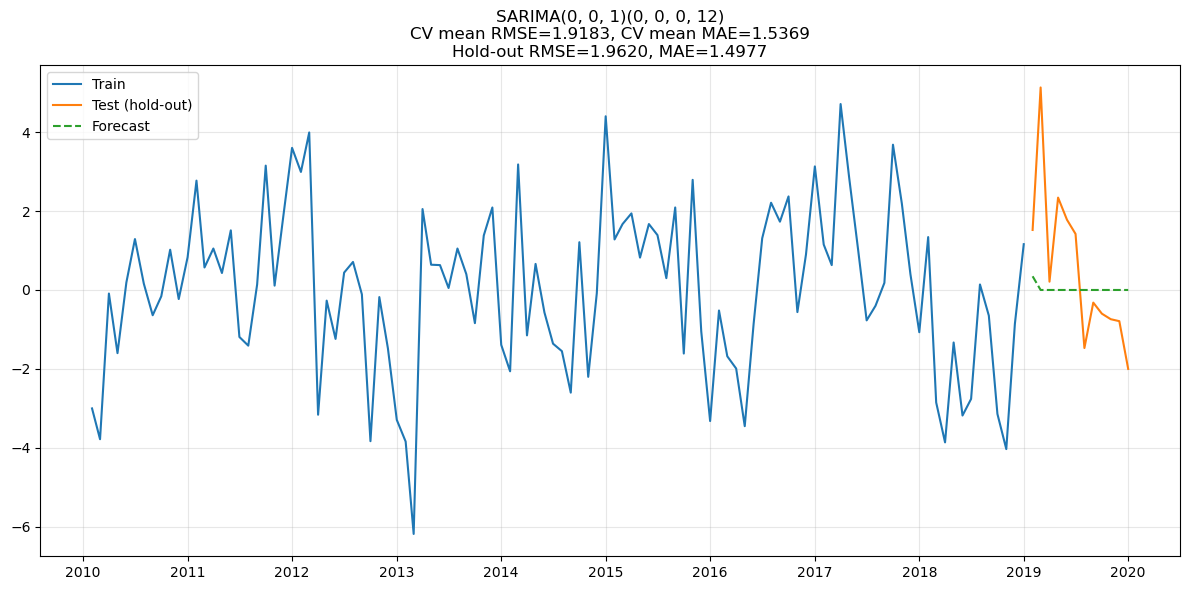

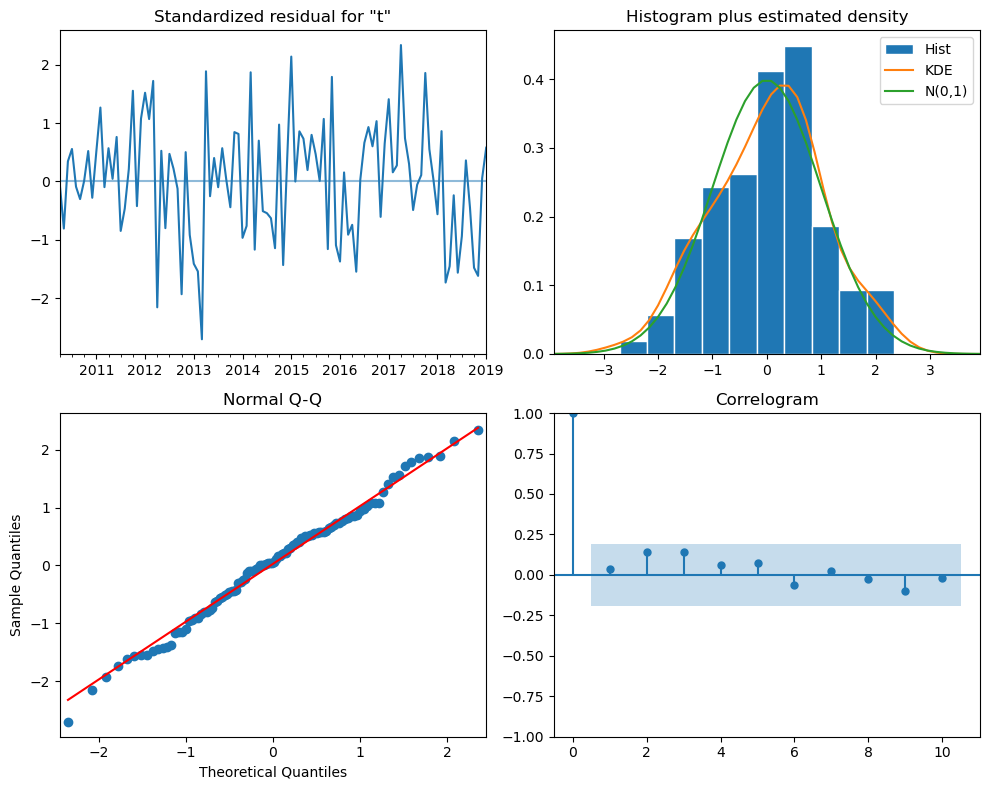

{'results': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper at 0x73dc2f430910>,
 'forecast': date
 2019-02-01    0.3471
 2019-03-01    0.0000
 2019-04-01    0.0000
 2019-05-01    0.0000
 2019-06-01    0.0000
 2019-07-01    0.0000
 2019-08-01    0.0000
 2019-09-01    0.0000
 2019-10-01    0.0000
 2019-11-01    0.0000
 2019-12-01    0.0000
 2020-01-01    0.0000
 Name: predicted_mean, dtype: float64,
 'test': date
 2019-02-01    1.52
 2019-03-01    5.13
 2019-04-01    0.21
 2019-05-01    2.34
 2019-06-01    1.78
 2019-07-01    1.42
 2019-08-01   -1.47
 2019-09-01   -0.32
 2019-10-01   -0.60
 2019-11-01   -0.74
 2019-12-01   -0.79
 2020-01-01   -2.00
 Name: t_seasdiff, dtype: float64,
 'rmse': np.float64(1.9619737784517817),
 'mae': 1.497741626807774}

In [8]:
plot_best_sarimax_final(
    df=data_sd,
    target=target,
    best_info=best_info,
    forecast_window=h,
    train_size=train_size,  # or None to use all data before last 12 months
    exog=None,              # or list of exogenous columns
)